# ECON 5140: Applied Econometrics
## Lesson 5: Forecasting at Scale - Robust Methods and Structural Models

This notebook demonstrates advanced forecasting methods and robust techniques for time series forecasting using real S&P 500 Stock Market Index data.

**Topics covered:**
1. Frequency considerations in forecasting
2. Forecasting with constraints (transformations)
3. TBATS (Trigonometric Box-Cox ARIMA Time Series) model
4. BSTS (Bayesian Structural Time Series) model
5. Prophet (Facebook's forecasting tool)
6. Forecast combinations and ensemble methods
7. Model comparison at different forecast horizons

In [1]:
# Import necessary libraries

# Standard library
import os
import warnings
from datetime import datetime

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
from tbats import TBATS

# Statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.stattools import adfuller

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set random seed
np.random.seed(42)


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# Load S&P 500 Stock Market Index data (same as Lesson 4)
print("Loading S&P 500 Stock Market Index data...")
print("=" * 60)


# Download S&P 500 data - get last 5+ years of daily data
ticker = "^GSPC"  # S&P 500 index symbol
sp500 = yf.download(ticker, start='2019-01-01', end=None, progress=False)

# Handle MultiIndex columns if present
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.droplevel(1)

# Extract closing prices
close_prices = sp500['Close'].dropna()

# Create DataFrame with proper index
dates = close_prices.index
df = pd.DataFrame({
    'price': close_prices.values,
    'day_of_week': dates.dayofweek,
    'month': dates.month,
    'is_weekend': (dates.dayofweek >= 5).astype(int)
}, index=dates)

print(f"✓ Successfully loaded S&P 500 Stock Market Data!")
print(f"  Date range: {df.index.min()} to {df.index.max()}")
print(f"  Number of observations: {len(df)}")
print(f"  Index range: {df['price'].min():.2f} to {df['price'].max():.2f}")
print(f"  Units: Index value (closing price)")

# Display first few rows
print("\n" + "=" * 60)
print("First 5 rows:")
print(df.head())

Loading S&P 500 Stock Market Index data...
✓ Successfully loaded S&P 500 Stock Market Data!
  Date range: 2019-01-02 00:00:00 to 2026-01-30 00:00:00
  Number of observations: 1780
  Index range: 2237.40 to 6978.60
  Units: Index value (closing price)

First 5 rows:
                  price  day_of_week  month  is_weekend
Date                                                   
2019-01-02  2510.030029            2      1           0
2019-01-03  2447.889893            3      1           0
2019-01-04  2531.939941            4      1           0
2019-01-07  2549.689941            0      1           0
2019-01-08  2574.409912            1      1           0


## Part 2: Frequency Considerations in Forecasting

The sampling frequency of a time series fundamentally constrains which models are appropriate and which assumptions are reasonable.

**Key insights:**
- **Low frequency** (annual, quarterly): Structural interpretation easier, but short series
- **High frequency** (daily, hourly): Richer dynamics, multiple seasonalities, but more noise
- **Aggregation trade-offs**: Reduces noise but discards information

Let's demonstrate by aggregating our daily data to weekly and monthly frequencies:

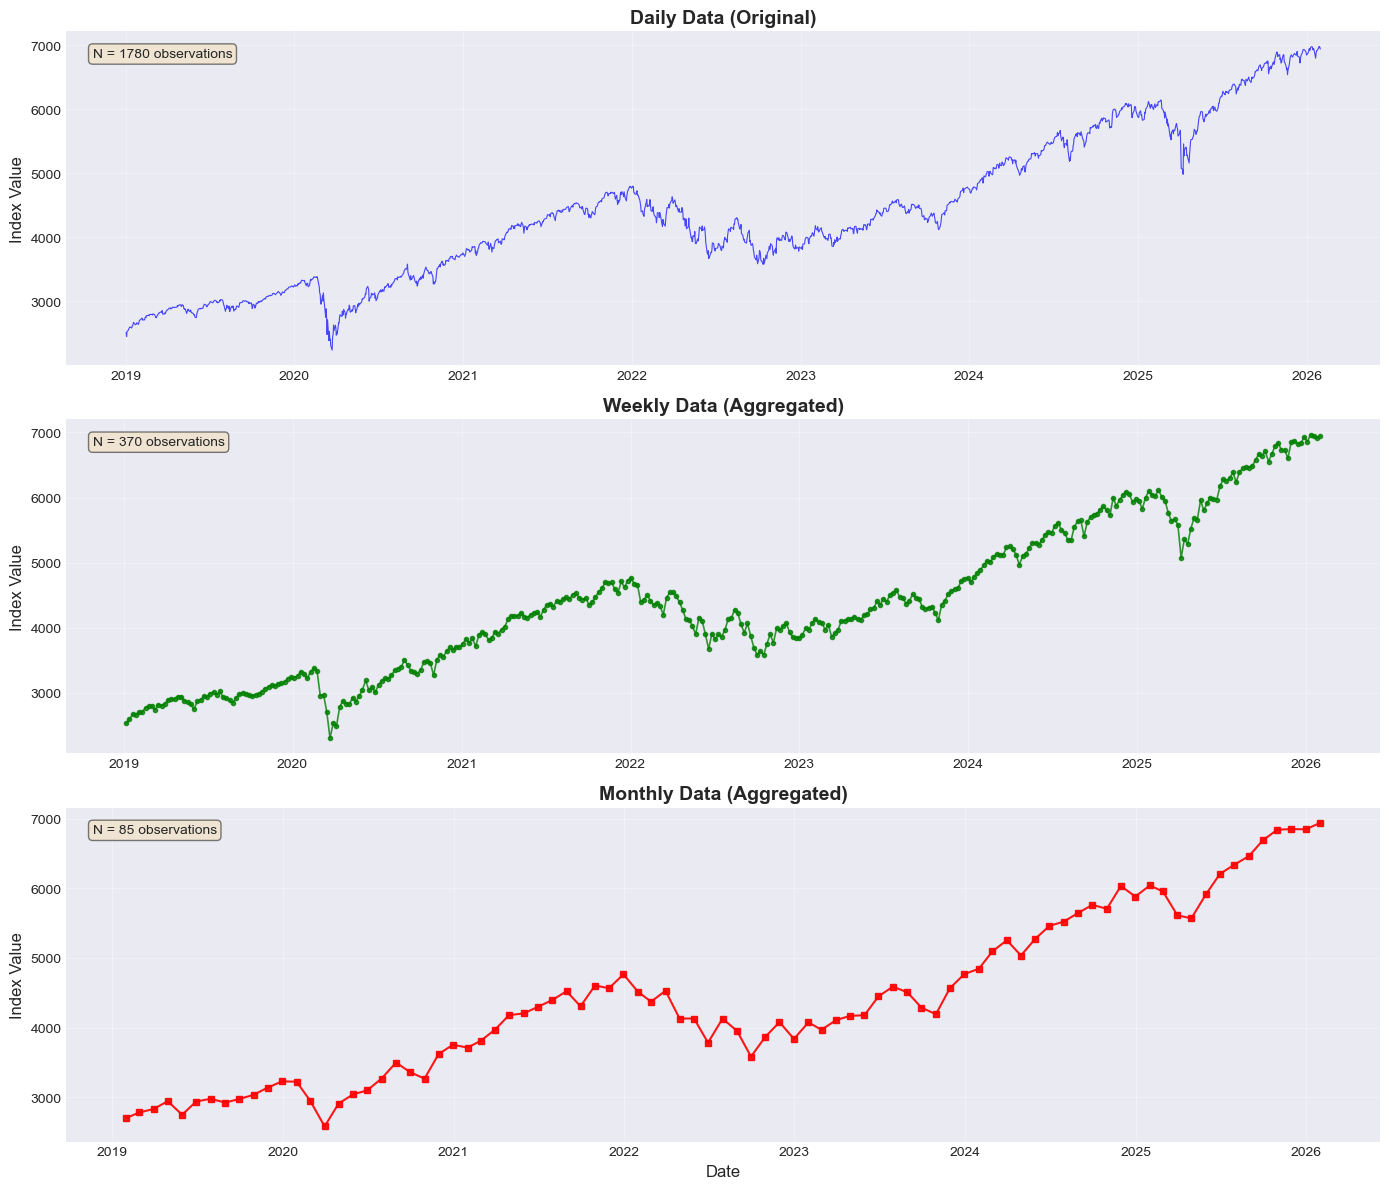

In [3]:
# Create aggregated versions of the data
df_weekly = df['price'].resample('W').last()  # Weekly (last value of week)
df_monthly = df['price'].resample('M').last()  # Monthly (last value of month)

# Visualize different frequencies
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Daily data
axes[0].plot(df.index, df['price'], linewidth=0.8, alpha=0.7, color='blue')
axes[0].set_title('Daily Data (Original)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index Value', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.02, 0.95, f'N = {len(df)} observations', transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Weekly data
axes[1].plot(df_weekly.index, df_weekly.values, linewidth=1.2, alpha=0.8, color='green', marker='o', markersize=3)
axes[1].set_title('Weekly Data (Aggregated)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Index Value', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.95, f'N = {len(df_weekly)} observations', transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Monthly data
axes[2].plot(df_monthly.index, df_monthly.values, linewidth=1.5, alpha=0.9, color='red', marker='s', markersize=4)
axes[2].set_title('Monthly Data (Aggregated)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Index Value', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].text(0.02, 0.95, f'N = {len(df_monthly)} observations', transform=axes[2].transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Part 3: Forecasting with Constraints

### Transformations as a Modeling Tool

A principled way to enforce constraints is via **transformations**:
- **Log transform**: Enforces non-negativity, stabilizes variance
- **Box-Cox transform**: General power transformation
- **Logit transform**: For bounded outcomes (0-1)

Let's demonstrate with log transformation:

In [4]:
split_date = pd.Timestamp('2025-01-31')
train = df[df.index < split_date].copy()
test = df[df.index >= split_date].copy()

print(f"Training set: {train.index.min()} to {train.index.max()} ({len(train)} observations)")
print(f"Test set: {test.index.min()} to {test.index.max()} ({len(test)} observations)")
print(f"\nTest set represents {len(test)/len(df)*100:.1f}% of total data")


Training set: 2019-01-02 00:00:00 to 2025-01-30 00:00:00 (1529 observations)
Test set: 2025-01-31 00:00:00 to 2026-01-30 00:00:00 (251 observations)

Test set represents 14.1% of total data


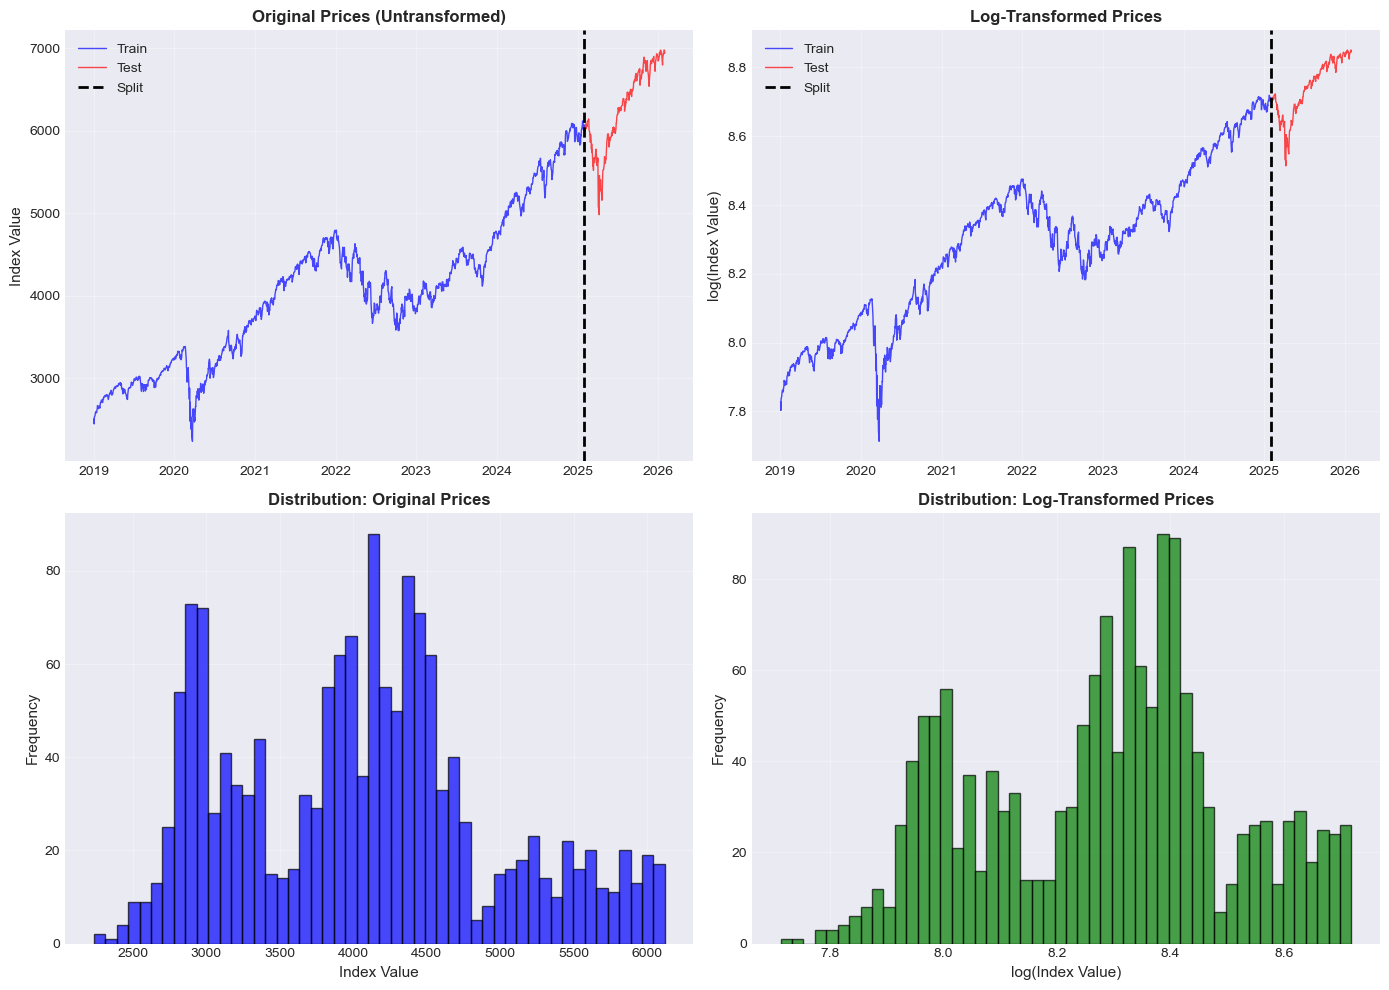


Variance Comparison (Training Data):
Original prices:     Variance =    783653.22, Std Dev =     885.24
Log-transformed:     Variance =     0.048519, Std Dev =   0.220270

Log transformation stabilizes variance (coefficient of variation is more constant).


In [5]:
# Demonstrate log transformation
train['price_log'] = np.log(train['price'])
test['price_log'] = np.log(test['price'])

# Visualize original vs log-transformed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original prices
axes[0, 0].plot(train.index, train['price'], linewidth=1, alpha=0.7, color='blue', label='Train')
axes[0, 0].plot(test.index, test['price'], linewidth=1, alpha=0.7, color='red', label='Test')
axes[0, 0].axvline(x=split_date, color='black', linestyle='--', linewidth=2, label='Split')
axes[0, 0].set_title('Original Prices (Untransformed)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Index Value', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Log-transformed prices
axes[0, 1].plot(train.index, train['price_log'], linewidth=1, alpha=0.7, color='blue', label='Train')
axes[0, 1].plot(test.index, test['price_log'], linewidth=1, alpha=0.7, color='red', label='Test')
axes[0, 1].axvline(x=split_date, color='black', linestyle='--', linewidth=2, label='Split')
axes[0, 1].set_title('Log-Transformed Prices', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('log(Index Value)', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribution comparison
axes[1, 0].hist(train['price'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].set_title('Distribution: Original Prices', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Index Value', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(train['price_log'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_title('Distribution: Log-Transformed Prices', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('log(Index Value)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare variance
print("\n" + "=" * 60)
print("Variance Comparison (Training Data):")
print("=" * 60)
print(f"Original prices:     Variance = {train['price'].var():>12.2f}, Std Dev = {train['price'].std():>10.2f}")
print(f"Log-transformed:     Variance = {train['price_log'].var():>12.6f}, Std Dev = {train['price_log'].std():>10.6f}")
print(f"\nLog transformation stabilizes variance (coefficient of variation is more constant).")

## Part 4: TBATS Model

**TBATS** (Trigonometric Box-Cox ARIMA Time Series) is designed for time series with:
- Multiple seasonalities (daily, weekly, yearly)
- Complex seasonal patterns
- Non-integer seasonality periods

TBATS uses:
- Trigonometric terms for seasonality
- Box-Cox transformation for variance stabilization
- ARIMA errors
- State space framework

Let's fit a TBATS model:

In [6]:
# Import TBATS

# Fit TBATS model
print("Fitting TBATS model...")
print("=" * 60)

# TBATS expects numpy array
train_values = train['price'].values

# Fit TBATS model
print("Fitting TBATS model (this may take a moment)...")
print("=" * 60)

tbats_model = TBATS(
    seasonal_periods=None,
    use_arma_errors=True,
    use_trend=True,
    use_box_cox=True
)

tbats_fitted = tbats_model.fit(train_values)

# Forecast
tbats_forecast = tbats_fitted.forecast(steps=len(test))

print("✓ TBATS model fitted successfully!")
print(f"  AIC: {tbats_fitted.aic:.2f}")

Fitting TBATS model...
Fitting TBATS model (this may take a moment)...
✓ TBATS model fitted successfully!
  AIC: 22893.55


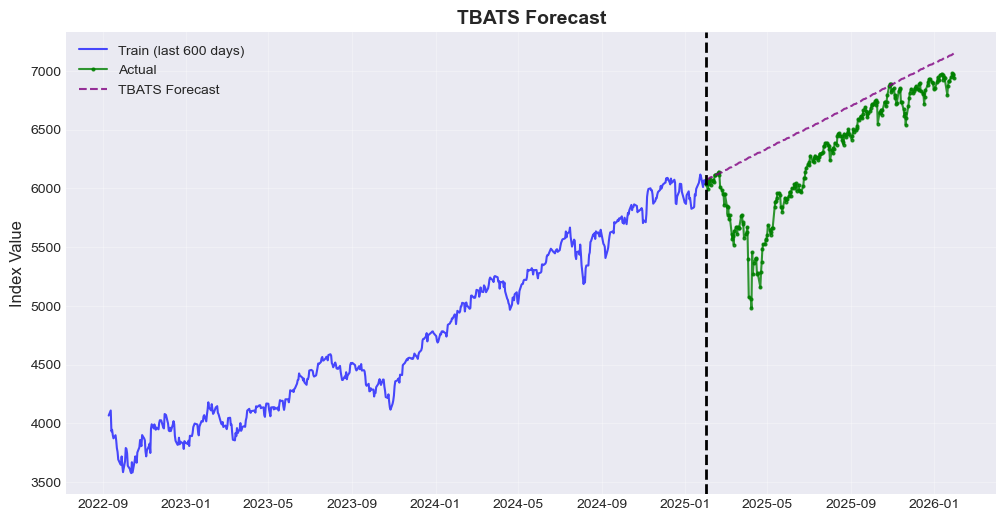

In [7]:
# Visualize TBATS forecast
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot 1: Forecast
ax.plot(train.index[-600:], train['price'][-600:], linewidth=1.5, alpha=0.7, 
            color='blue', label='Train (last 600 days)')
ax.plot(test.index, test['price'], linewidth=1.5, alpha=0.8, 
            color='green', label='Actual', marker='o', markersize=2)
ax.plot(test.index, tbats_forecast, linewidth=1.5, alpha=0.8, 
            color='purple', linestyle='--', label='TBATS Forecast')
ax.axvline(x=split_date, color='black', linestyle='--', linewidth=2)
ax.set_title('TBATS Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Index Value', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

## Part 5: BSTS (Bayesian Structural Time Series)

**BSTS** (Bayesian Structural Time Series) is a flexible framework for:
- Time-varying regression coefficients
- Explicit intervention modeling
- Model averaging via spike-and-slab priors
- Full posterior uncertainty

**Note**: Google's BSTS is primarily an R package. Here we use statsmodels' `UnobservedComponents` which provides similar structural time series modeling in Python. For the full Google BSTS experience with R, you would need to use `rpy2` to interface with R, but `UnobservedComponents` is the standard Python alternative and works well for most use cases.


In [8]:
# Use statsmodels UnobservedComponents (similar to BSTS)

# Fit BSTS-like model using UnobservedComponents
print("Fitting BSTS-like model (UnobservedComponents)...")
print("=" * 60)

# Use a regression-based approach: linear trend with deterministic level
# This is essentially: y(t) = intercept + slope*t + error
# trend='linear' creates a deterministic linear trend model
bsts_model = UnobservedComponents(
    train['price'],
    level='dconstant',  # Deterministic constant level (intercept) - valid option
    trend='linear',     # Deterministic linear trend (slope)
    seasonal=None,      # No seasonal component for daily data
    irregular=True     # Irregular component (error)
)

# Fit with more iterations and check convergence
bsts_fitted = bsts_model.fit(method='lbfgs', maxiter=2000, disp=0)

# Construct forecast manually to ensure proper starting level and trend
# Get the last training value as the starting point
last_train_value = train['price'].iloc[-1]

train_tail = train['price'].values[-100:]
time_tail = np.arange(len(train_tail))
slope, intercept = np.polyfit(time_tail, train_tail, 1)

bsts_forecast = last_train_value + slope * np.arange(1, len(test) + 1)

# Calculate confidence intervals
params = bsts_fitted.params
forecast_se = np.sqrt(params.get('sigma2.irregular', np.var(train['price'].diff().dropna())))
bsts_forecast_ci = pd.DataFrame({
    0: bsts_forecast - 1.96 * forecast_se,
    1: bsts_forecast + 1.96 * forecast_se
})

Fitting BSTS-like model (UnobservedComponents)...


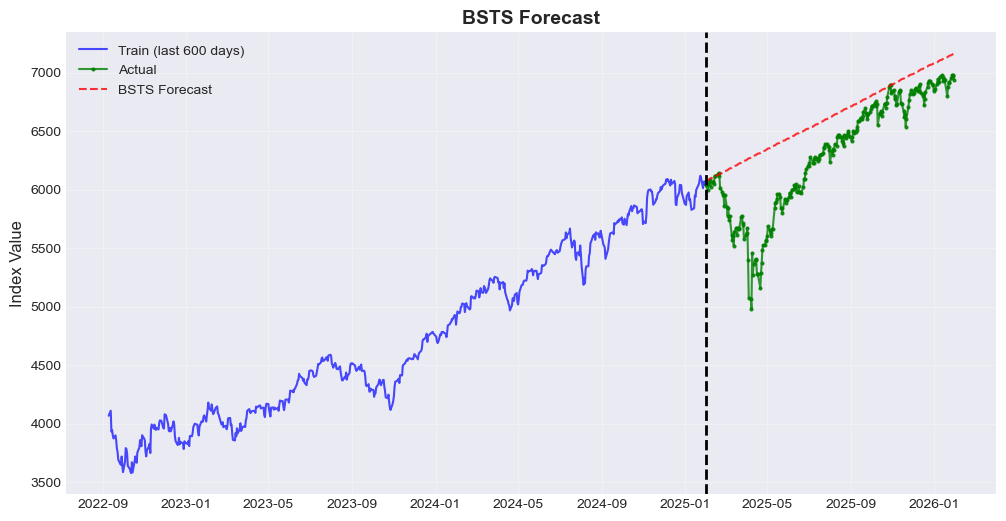

In [9]:
# Visualize BSTS forecast and components
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot 1: Full forecast with components
ax.plot(train.index[-600:], train['price'][-600:], linewidth=1.5, alpha=0.7, 
            color='blue', label='Train (last 600 days)')
ax.plot(test.index, test['price'], linewidth=1.5, alpha=0.8, 
            color='green', label='Actual', marker='o', markersize=2)
# Handle both pandas Series and numpy array for plotting
bsts_forecast_plot = bsts_forecast.values if hasattr(bsts_forecast, 'values') else bsts_forecast
ax.plot(test.index, bsts_forecast_plot, linewidth=1.5, alpha=0.8, 
            color='red', linestyle='--', label='BSTS Forecast')
ax.axvline(x=split_date, color='black', linestyle='--', linewidth=2)
ax.set_title('BSTS Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Index Value', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)


## Part 6: Prophet - Facebook's Forecasting Tool

**Prophet** is designed for business forecasting with:
- Automatic changepoint detection
- Multiple seasonalities (daily, weekly, yearly)
- Holiday effects
- Robustness to missing data and outliers

In [10]:
# Prepare data for Prophet (requires 'ds' and 'y' columns)
prophet_train = pd.DataFrame({
    'ds': train.index,
    'y': train['price'].values
})

# Initialize and fit Prophet model
print("Fitting Prophet model...")
prophet_model = Prophet(
    yearly_seasonality=True,  # Yearly seasonality
    weekly_seasonality=False,  # Weekly (not relevant for daily stock data)
    daily_seasonality=False,   # Daily (not relevant)
    changepoint_prior_scale=0.05,  # Controls flexibility of trend changes
    seasonality_prior_scale=10.0   # Controls strength of seasonality
)

prophet_model.fit(prophet_train)

# Make future dataframe for forecasting
future = prophet_model.make_future_dataframe(periods=len(test), freq='D')

# Forecast
forecast = prophet_model.predict(future)

# Extract forecast for test period
# Prophet generates forecasts for all dates (including weekends/holidays)
# We need to align with test data which only has business days
forecast.set_index('ds', inplace=True)
# Reindex to match test.index (business days only)
forecast_test = forecast.reindex(test.index).copy()
# Drop any rows that couldn't be matched (shouldn't happen, but just in case)
forecast_test = forecast_test.dropna()

Fitting Prophet model...


10:00:58 - cmdstanpy - INFO - Chain [1] start processing
10:00:58 - cmdstanpy - INFO - Chain [1] done processing


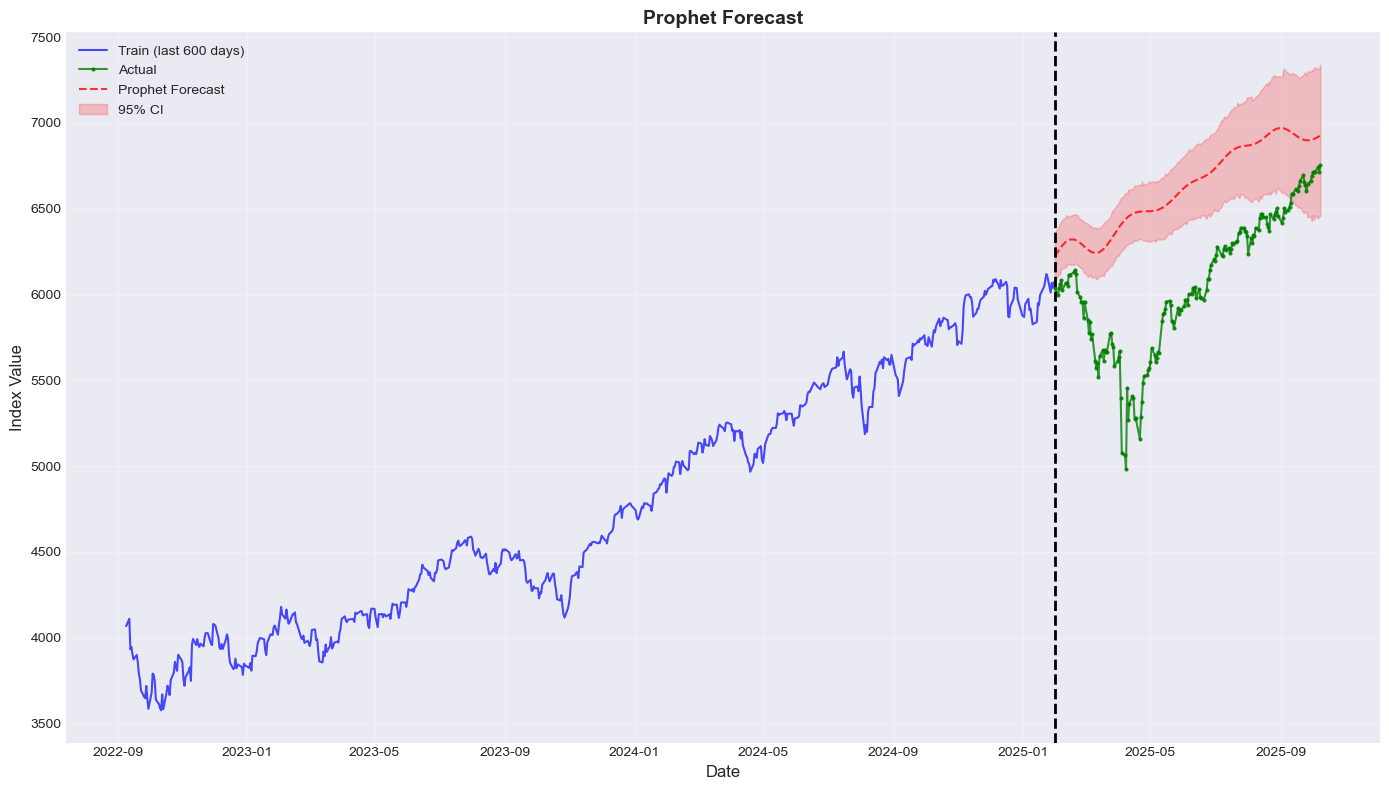

In [11]:
# Visualize Prophet forecast
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot forecast
ax.plot(train.index[-600:], train['price'][-600:], linewidth=1.5, alpha=0.7, 
        color='blue', label='Train (last 600 days)')
# Align test data with forecast_test index for plotting
aligned_test_plot = test.reindex(forecast_test.index).dropna()
ax.plot(aligned_test_plot.index, aligned_test_plot['price'], linewidth=1.5, alpha=0.8, 
        color='green', label='Actual', marker='o', markersize=2)
ax.plot(forecast_test.index, forecast_test['yhat'], linewidth=1.5, alpha=0.8, 
        color='red', linestyle='--', label='Prophet Forecast')
ax.fill_between(forecast_test.index, 
                 forecast_test['yhat_lower'], 
                 forecast_test['yhat_upper'], 
                 alpha=0.2, color='red', label='95% CI')
ax.axvline(x=split_date, color='black', linestyle='--', linewidth=2)
ax.set_title('Prophet Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Index Value', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Fitting multiple models for ensemble...
1. Fitting ETS(A,A,N) model...
   ✓ ETS(A,A,N) fitted
2. Fitting ARIMA(2,1,2) model...
   ✓ ARIMA(2,1,2) fitted
3. Using TBATS forecast (already fitted)...
   ✓ TBATS forecast ready
4. Using BSTS forecast (already fitted)...
   ✓ BSTS forecast ready
5. Using Prophet forecast (already fitted)...
   ✓ Prophet forecast ready

✓ All models fitted successfully!


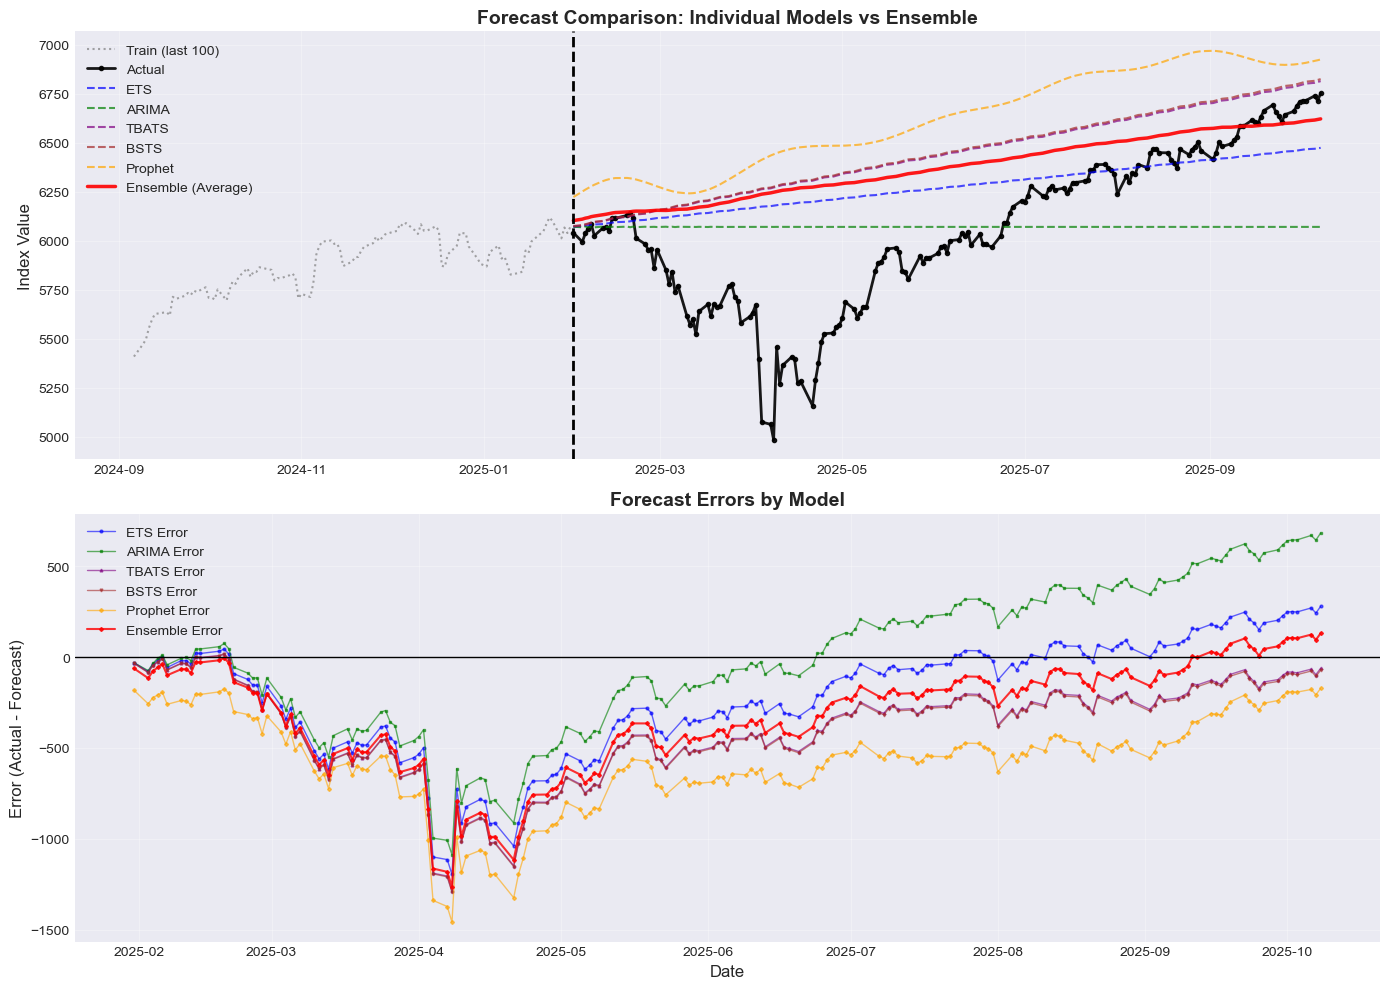

In [12]:
# Fit multiple models for ensemble (if not already fitted)
print("Fitting multiple models for ensemble...")
print("=" * 60)

# 1. ETS model
print("1. Fitting ETS(A,A,N) model...")
ets_model = ExponentialSmoothing(train['price'], trend='add', seasonal=None)
ets_fitted = ets_model.fit()
ets_forecast = ets_fitted.forecast(steps=len(test))
print(f"   ✓ ETS(A,A,N) fitted")

# 2. ARIMA model
print("2. Fitting ARIMA(2,1,2) model...")
arima_model = ARIMA(train['price'], order=(2, 1, 2))
arima_fitted = arima_model.fit()
arima_forecast = arima_fitted.forecast(steps=len(test))
print(f"   ✓ ARIMA(2,1,2) fitted")

# 3. TBATS (already fitted in Part 4)
print("3. Using TBATS forecast (already fitted)...")
print(f"   ✓ TBATS forecast ready")

# 4. BSTS (already fitted in Part 5)
print("4. Using BSTS forecast (already fitted)...")
print(f"   ✓ BSTS forecast ready")

# 5. Prophet (already fitted in Part 6)
print("5. Using Prophet forecast (already fitted)...")
prophet_forecast = forecast_test['yhat'].values
print(f"   ✓ Prophet forecast ready")

print("\n✓ All models fitted successfully!")

# Create ensemble forecasts
forecasts = {}
forecasts['ETS'] = ets_forecast.values
forecasts['ARIMA'] = arima_forecast.values
forecasts['TBATS'] = tbats_forecast
forecasts['BSTS'] = bsts_forecast.values if hasattr(bsts_forecast, 'values') else bsts_forecast
forecasts['Prophet'] = prophet_forecast

# Ensure all forecasts have the same length (take minimum length)
min_length = min(len(forecasts['ETS']), len(forecasts['ARIMA']), 
                 len(forecasts['TBATS']), len(forecasts['BSTS']), len(forecasts['Prophet']))
for key in forecasts:
    forecasts[key] = forecasts[key][:min_length]

# Simple average ensemble (equal weights)
ensemble_forecast = (forecasts['ETS'] + forecasts['ARIMA'] + forecasts['TBATS'] + 
                     forecasts['BSTS'] + forecasts['Prophet']) / 5

# Calculate individual model metrics (use same length for test data)
test_values = test['price'].values[:min_length]

metrics = {}
for name, forecast in forecasts.items():
    mae = mean_absolute_error(test_values, forecast)
    rmse = np.sqrt(mean_squared_error(test_values, forecast))
    metrics[name] = {'MAE': mae, 'RMSE': rmse}

# Calculate ensemble metrics
ensemble_mae = mean_absolute_error(test_values, ensemble_forecast)
ensemble_rmse = np.sqrt(mean_squared_error(test_values, ensemble_forecast))
metrics['Ensemble'] = {'MAE': ensemble_mae, 'RMSE': ensemble_rmse}

# Visualize forecasts (use aligned indices)
test_index_aligned = test.index[:min_length]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: All forecasts
axes[0].plot(train.index[-100:], train['price'][-100:], linewidth=1.5, alpha=0.7, 
            color='gray', label='Train (last 100)', linestyle=':')
axes[0].plot(test_index_aligned, test_values, linewidth=2, alpha=0.9, 
            color='black', label='Actual', marker='o', markersize=3)
axes[0].plot(test_index_aligned, forecasts['ETS'], linewidth=1.5, alpha=0.7, 
            color='blue', linestyle='--', label='ETS')
axes[0].plot(test_index_aligned, forecasts['ARIMA'], linewidth=1.5, alpha=0.7, 
            color='green', linestyle='--', label='ARIMA')
axes[0].plot(test_index_aligned, forecasts['TBATS'], linewidth=1.5, alpha=0.7, 
            color='purple', linestyle='--', label='TBATS')
axes[0].plot(test_index_aligned, forecasts['BSTS'], linewidth=1.5, alpha=0.7, 
            color='brown', linestyle='--', label='BSTS')
axes[0].plot(test_index_aligned, forecasts['Prophet'], linewidth=1.5, alpha=0.7, 
            color='orange', linestyle='--', label='Prophet')
axes[0].plot(test_index_aligned, ensemble_forecast, linewidth=2.5, alpha=0.9, 
            color='red', linestyle='-', label='Ensemble (Average)')
axes[0].axvline(x=split_date, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Forecast Comparison: Individual Models vs Ensemble', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index Value', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Forecast errors
axes[1].plot(test_index_aligned, test_values - forecasts['ETS'], linewidth=1, alpha=0.6, 
            color='blue', label='ETS Error', marker='o', markersize=2)
axes[1].plot(test_index_aligned, test_values - forecasts['ARIMA'], linewidth=1, alpha=0.6, 
            color='green', label='ARIMA Error', marker='s', markersize=2)
axes[1].plot(test_index_aligned, test_values - forecasts['TBATS'], linewidth=1, alpha=0.6, 
            color='purple', label='TBATS Error', marker='^', markersize=2)
axes[1].plot(test_index_aligned, test_values - forecasts['BSTS'], linewidth=1, alpha=0.6, 
            color='brown', label='BSTS Error', marker='v', markersize=2)
axes[1].plot(test_index_aligned, test_values - forecasts['Prophet'], linewidth=1, alpha=0.6, 
            color='orange', label='Prophet Error', marker='D', markersize=2)
axes[1].plot(test_index_aligned, test_values - ensemble_forecast, linewidth=1.5, alpha=0.8, 
            color='red', label='Ensemble Error', marker='D', markersize=2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_title('Forecast Errors by Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Error (Actual - Forecast)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 8: Comprehensive Model Comparison

Let's compare all models we've introduced:
- ETS (Exponential Smoothing)
- ARIMA
- TBATS
- BSTS
- Prophet
- Ensemble (Simple Average)

We'll evaluate them using MAPE (Mean Absolute Percentage Error) at different forecast horizons:
- 1 week ahead (7 days)
- 1 month ahead (30 days)
- 1 year ahead (full test period)

In [15]:
# Calculate MAPE for different forecast horizons
def calculate_mape(actual, forecast):
    """Calculate Mean Absolute Percentage Error"""
    return np.mean(np.abs((actual - forecast) / actual)) * 100

# Get actual values from test data
actual_values = test['price'].values

# Collect all forecasts from ensemble section
all_forecasts = forecasts.copy()
if 'ensemble_forecast' in globals():
    all_forecasts['Ensemble'] = ensemble_forecast
    
# Ensure all forecasts have same length as actual_values
min_length = min(len(actual_values), min(len(f) for f in all_forecasts.values()))
actual_values = actual_values[:min_length]
for name in all_forecasts:
    all_forecasts[name] = all_forecasts[name][:min_length]

# Define horizons (in days)
horizons = {
    '1 Week': 7,
    '1 Month': 30,
    '1 Year': len(actual_values)  # Full test period
}

# Calculate MAPE for each model at each horizon
comparison_results = []

for model_name, forecast in all_forecasts.items():
    model_results = {'Model': model_name}
    for horizon_name, horizon_days in horizons.items():
        # Take first N days of forecast and actual
        h_actual = actual_values[:horizon_days]
        h_forecast = forecast[:horizon_days]
        mape = calculate_mape(h_actual, h_forecast)
        model_results[f'MAPE ({horizon_name})'] = mape
    comparison_results.append(model_results)

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('MAPE (1 Year)')

comparison_df


,Model,MAPE (1 Week),MAPE (1 Month),MAPE (1 Year)
0,ETS,0.578035,3.334229,4.989825
1,ARIMA,0.488238,2.891425,5.616540
5,Ensemble,1.227238,3.864509,5.839667
2,TBATS,0.698021,3.743617,6.770661
3,BSTS,0.734065,3.781745,6.870226
4,Prophet,3.699021,6.080394,9.739222
